![logo](img/logoitqv1.jpg)
<br>
# 0.1 PAO26-26 - Python 101, Descriptores de Forma
<br>

![python](img/python_logo.png)

<br>

*Kenin CUsme*

<br>

[link de Git Hub](https://github.com/kenin395/Machine-Learning.git)

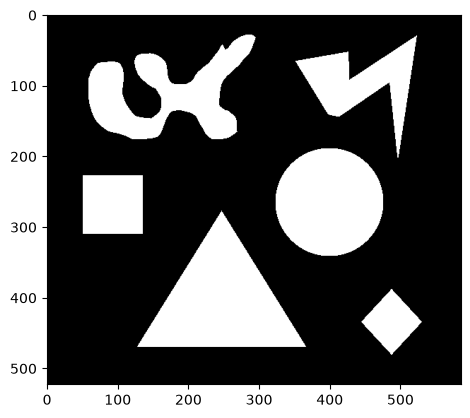

In [1]:
 # En primer lugar, obtenemos la máscara de la imagen original mediante la␣umbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np
img = cv2.imread('images/figuras.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(img_gray,0,1,cv2.THRESH_OTSU)
plt.imshow(mask, cmap='gray')
plt.show()


número de objetos:  6
posibles valores de intensidad:  [0 1 2 3 4 5 6]


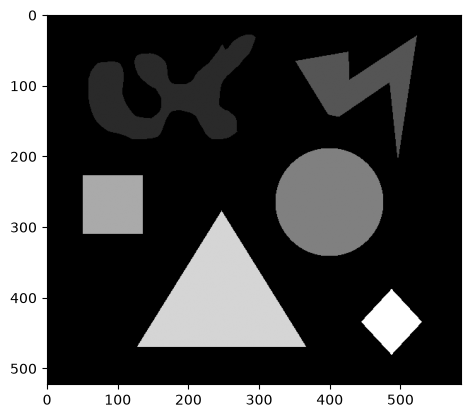

In [2]:
# Convertimos la imagen binaria en una imagen de etiquetas para tener acceso a␣cada objeto por separado
from skimage.measure import label
lab, num = label(mask, return_num=True)
# Importante:
# En 'num' devuelve 6 valores correspondientes a los 6 objetos que hay en la␣imagen.
# Sin embargo, 'lab' contiene hasta 7 valores diferentes, ya que también tiene␣en cuenta el fondo de la imagen.
print('número de objetos: ', num)
v,c = np.unique(lab, return_counts=True)
print('posibles valores de intensidad: ', v)
plt.imshow(lab, cmap='gray')
plt.show()

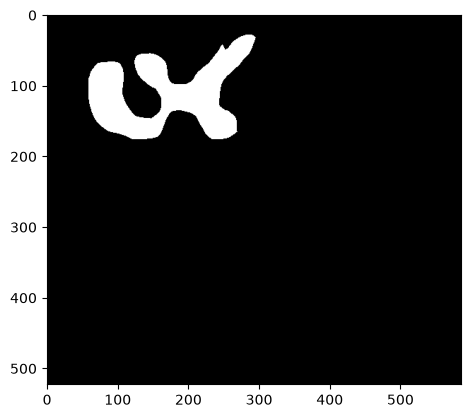

In [3]:
# Podemos acceder de manera independiente al objeto que nos interese a partir␣de su etiqueta correspondiente
objeto = lab == 1
objeto = objeto.astype('uint8')
plt.imshow(objeto, cmap='gray')
plt.show()


(28, 59, 176, 296)


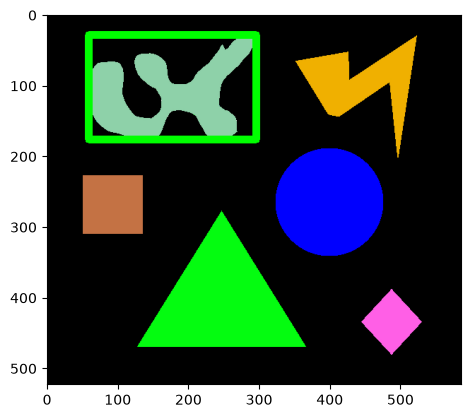

In [4]:
from skimage.measure import regionprops
# https://scikit-image.org/docs/dev/api/skimage.measure.html#skimage.measure.regionprops
# Después, podemos extraer la bounding box de dicho objeto
prop = regionprops(objeto)
bbox = prop[0].bbox
print(bbox)
start_point = (bbox[1], bbox[0])
end_point = (bbox[3], bbox[2])
window = cv2.rectangle(img.copy(), start_point, end_point, (0, 255, 0), 10)
plt.imshow(window, cmap='gray')
plt.show()

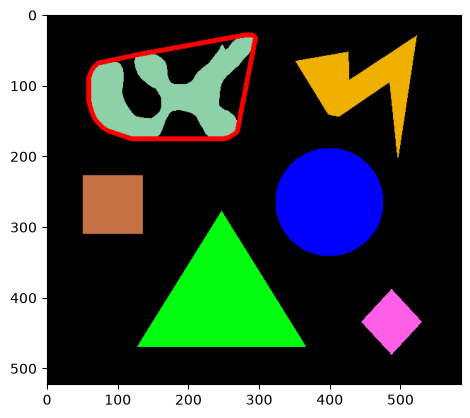

In [5]:
# Y la convex hull image
from skimage.morphology import convex_hull_image
convex_image = convex_hull_image(objeto)
convex_image = convex_image.astype('uint8')
# plt.imshow(convex_image, cmap='gray')
# plt.show()
conts,_ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) # Encontramos los contornos en una máscara
imagen = cv2.drawContours(img.copy(), conts, -1, (255,0,0), 5) # Dibujamos los␣contornos
plt.imshow(imagen, cmap='gray')
plt.show()


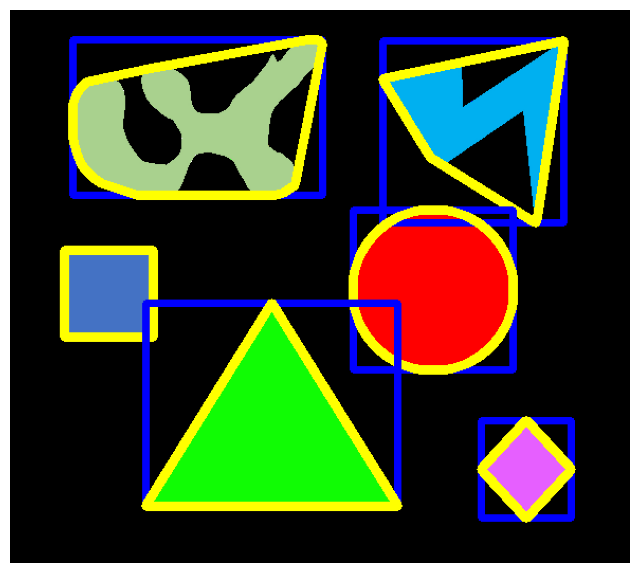

In [7]:
import cv2
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from skimage.morphology import convex_hull_image

# Repetimos el proceso completo para todos los objetos de la imagen
imagen = img.copy()

for i in range(1, num + 1):
    # Máscara del objeto
    objeto = (lab == i).astype('uint8')

    # Bounding Box
    prop = regionprops(objeto)
    bbox = prop[0].bbox  # (min_row, min_col, max_row, max_col)

    imagen = cv2.rectangle(
        imagen,
        (bbox[1], bbox[0]),
        (bbox[3] - 1, bbox[2] - 1),
        (255, 0, 0),
        5
    )

    # Convex Hull
    convex_image = convex_hull_image(objeto)
    convex_image = convex_image.astype('uint8')

    conts, _ = cv2.findContours(
        convex_image,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    imagen = cv2.drawContours(
        imagen,
        conts,
        -1,
        (0, 255, 255),
        8
    )

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [9]:
# Vamos a extraer diferentes descriptores geométricos que nos ayudarán a caracterizar los objetos

import numpy as np
import math
from tabulate import tabulate
from skimage.measure import label, regionprops

# Etiquetar los objetos
new_lab, new_num = label(mask, return_num=True)

# Encabezados de la tabla
headers = ['', 'Raro', 'Rayo', 'Círculo', 'Cuadrado', 'Triángulo', 'Rombo']

# Listas para almacenar los descriptores
A = ['Área']
BB = ['Área Bounding Box']
CA = ['Área Convexa']
E = ['Excentricidad']
ED = ['Diámetro Equivalente']
EX = ['Extensión']
MA = ['Eje Mayor']
MiA = ['Eje Menor']
OR = ['Orientación']
P = ['Perímetro']
S = ['Solidez']
CO = ['Compacidad']
R = ['Rectangularidad']

# Extraer las características geométricas
for i in range(1, new_num + 1):

    objeto = (new_lab == i).astype(np.uint8)
    prop = regionprops(objeto)[0]

    A.append(round(prop.area, 4))
    BB.append(round(prop.area_bbox, 4))
    CA.append(round(prop.area_convex, 4))
    E.append(round(prop.eccentricity, 4))
    ED.append(round(prop.equivalent_diameter_area, 4))
    EX.append(round(prop.extent, 4))
    MA.append(round(prop.axis_major_length, 4))
    MiA.append(round(prop.axis_minor_length, 4))
    OR.append(round(prop.orientation, 4))
    P.append(round(prop.perimeter, 4))
    S.append(round(prop.solidity, 4))

    # Evitar división por cero
    if prop.perimeter != 0:
        CO.append(round(4 * math.pi * prop.area / (prop.perimeter ** 2), 4))
    else:
        CO.append(0)

    if prop.area_bbox != 0:
        R.append(round(prop.area / prop.area_bbox, 4))
    else:
        R.append(0)

# Crear tabla
my_data = [
    A, BB, CA, E, ED, EX,
    MA, MiA, OR, P, S, CO, R
]

print(tabulate(my_data, headers=headers, tablefmt="grid"))

+----------------------+------------+------------+------------+------------+-------------+-----------+
|                      |       Raro |       Rayo |    Círculo |   Cuadrado |   Triángulo |     Rombo |
+======================+============+============+============+============+=============+===========+
| Área                 | 16198      | 10282      | 18344      |  7055      |  23119      | 4018      |
+----------------------+------------+------------+------------+------------+-------------+-----------+
| Área Bounding Box    | 35076      | 29756      | 23104      |  7055      |  46127      | 7998      |
+----------------------+------------+------------+------------+------------+-------------+-----------+
| Área Convexa         | 27405      | 16959      | 18488      |  7055      |  23307      | 4102      |
+----------------------+------------+------------+------------+------------+-------------+-----------+
| Excentricidad        |     0.8556 |     0.7941 |     0      |     0.215